# 01. Doanh thu tổng theo ngày (sales.csv)

**Mục tiêu:** Hiểu chuỗi doanh thu/giá vốn ngày mà BTC yêu cầu dự báo: phân phối, xu hướng nhiều năm, mùa vụ theo thứ và tháng, phân rã xu hướng – mùa vụ.

**Bảng dữ liệu dùng:** `sales`

In [1]:
import sys
from pathlib import Path

# Tìm thư mục gốc repo (chứa src/ds317) để import thư viện chung
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "ds317").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ds317 import load, load_many, order_lines, revenue_daily, weekly_category, REVENUE_LABELS
from ds317.viz import setup_style, nb_out, save_fig, source_note, key_numbers, MILLION, UNIT, NOTE_SALES, NOTE_TRAFFIC

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)
setup_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
FIG, TAB = nb_out("01_bien_muc_tieu_tong_theo_ngay")
print("Ảnh lưu tại:", FIG.relative_to(ROOT))

Ảnh lưu tại: outputs\eda\01_bien_muc_tieu_tong_theo_ngay


> `sales.Revenue` = SUM(`quantity × unit_price`) của mọi đơn đặt trong ngày: **doanh thu gộp, gồm đơn huỷ, trước chiết khấu**
> (đối soát chi tiết ở notebook 02). `sales.COGS` = SUM(`quantity × products.cogs`).

In [2]:
sales = load("sales")
sales["Gross_Profit"] = sales["Revenue"] - sales["COGS"]
sales["Gross_Margin_Pct"] = sales["Gross_Profit"] / sales["Revenue"] * 100
sales["Year"], sales["Month"], sales["DayOfWeek"] = sales.Date.dt.year, sales.Date.dt.month, sales.Date.dt.dayofweek
sales.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,3833,2017-10-02 00:00:00,2012-07-04 00:00:00,2015-02-17 00:00:00,2017-10-02 00:00:00,2020-05-17 00:00:00,2022-12-31 00:00:00,NaN
Revenue,3833.0,4286584.029619,279813.94,2471088.82,3647303.9,5350877.2,20905271.35,2624840.198186
COGS,3833.0,3695134.494957,236576.31,2150580.23,3161112.99,4637293.92,16535857.67,2219788.768582
Gross_Profit,3833.0,591449.534662,-2567311.72,229274.05,544554.38,876080.98,4369413.68,666196.022818
Gross_Margin_Pct,3833.0,12.539306,-57.457973,8.261275,17.830046,20.288745,28.691554,12.735614
Year,3833.0,2017.240543,2012.0,2015.0,2017.0,2020.0,2022.0,3.036754
Month,3833.0,6.665797,1.0,4.0,7.0,10.0,12.0,3.446462
DayOfWeek,3833.0,3.000522,0.0,1.0,3.0,5.0,6.0,1.999608


## Doanh thu, giá vốn, lợi nhuận gộp hằng ngày phân phối thế nào?

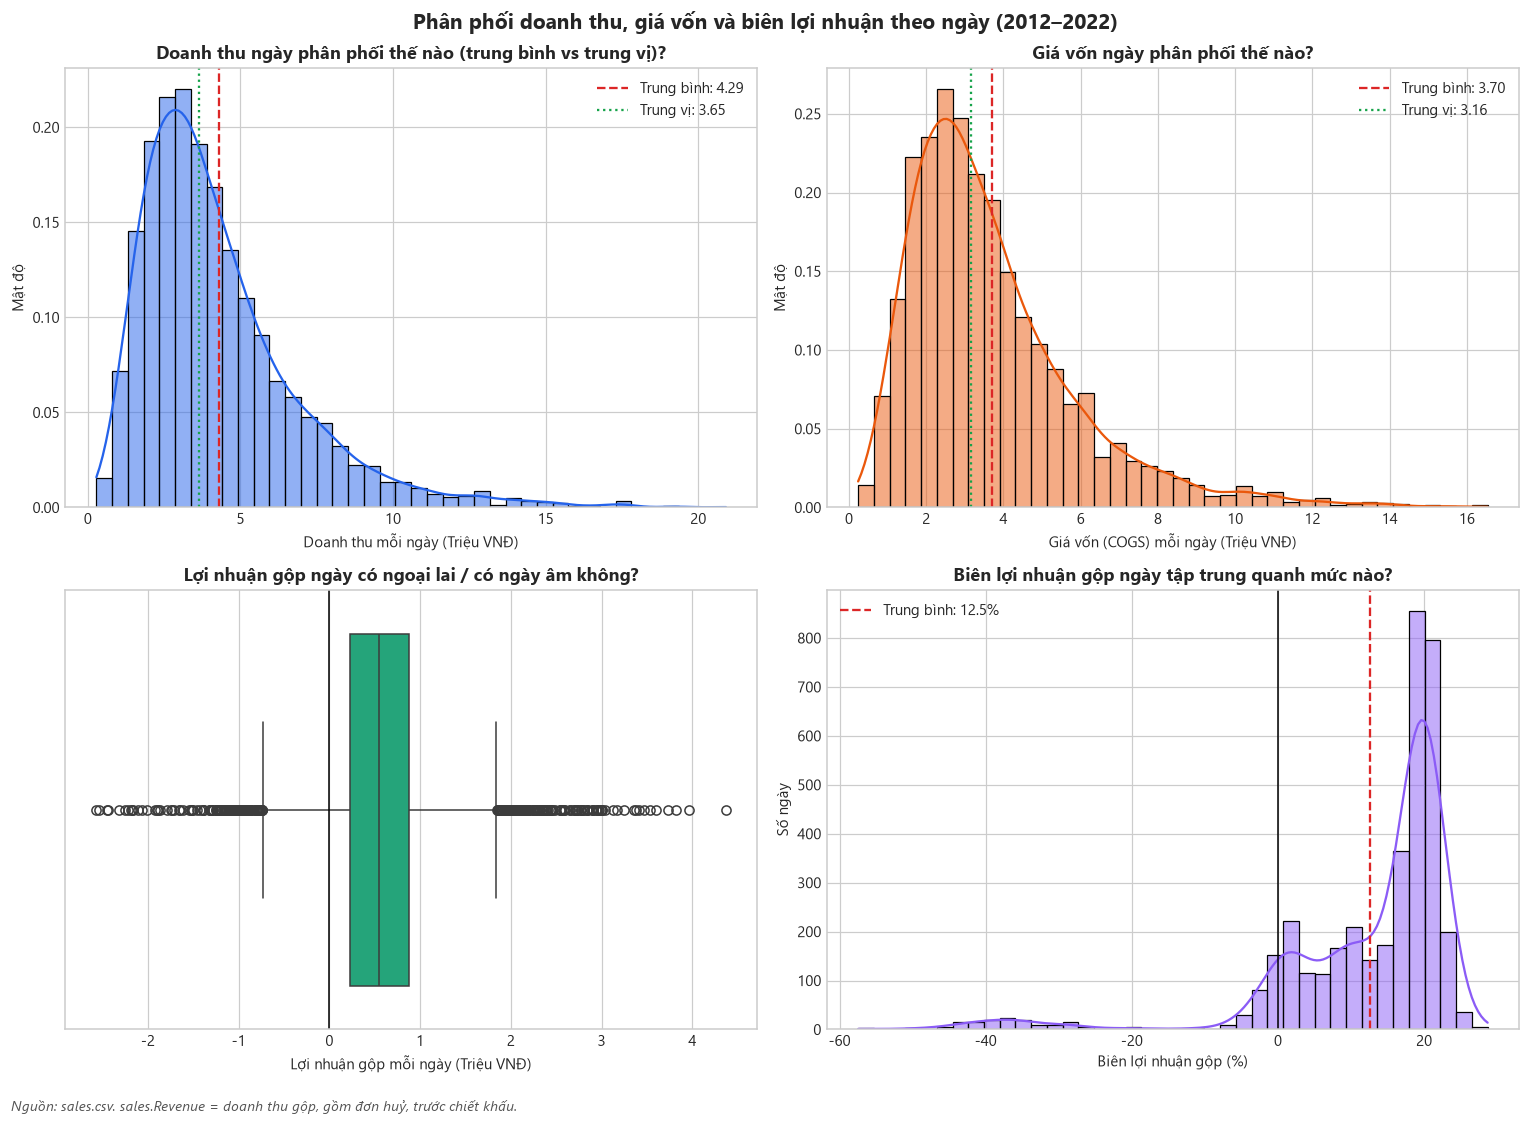

  đã lưu 01a_phan_phoi_doanh_thu.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, color, label in [(axes[0, 0], "Revenue", "#2563eb", "Doanh thu"), (axes[0, 1], "COGS", "#ea580c", "Giá vốn (COGS)")]:
    s = sales[col] / MILLION
    sns.histplot(s, kde=True, ax=ax, color=color, bins=40, stat="density")
    ax.axvline(s.mean(), color="#dc2626", ls="--", label=f"Trung bình: {s.mean():.2f}")
    ax.axvline(s.median(), color="#16a34a", ls=":", label=f"Trung vị: {s.median():.2f}")
    ax.set_xlabel(f"{label} mỗi ngày ({UNIT})")
    ax.set_ylabel("Mật độ")
    ax.legend()
axes[0, 0].set_title("Doanh thu ngày phân phối thế nào (trung bình vs trung vị)?", fontweight="bold")
axes[0, 1].set_title("Giá vốn ngày phân phối thế nào?", fontweight="bold")
sns.boxplot(x=sales["Gross_Profit"] / MILLION, ax=axes[1, 0], color="#10b981")
axes[1, 0].axvline(0, color="black", lw=1)
axes[1, 0].set_title("Lợi nhuận gộp ngày có ngoại lai / có ngày âm không?", fontweight="bold")
axes[1, 0].set_xlabel(f"Lợi nhuận gộp mỗi ngày ({UNIT})")
sns.histplot(sales["Gross_Margin_Pct"], kde=True, ax=axes[1, 1], color="#8b5cf6", bins=40)
axes[1, 1].axvline(sales["Gross_Margin_Pct"].mean(), color="#dc2626", ls="--", label=f"Trung bình: {sales.Gross_Margin_Pct.mean():.1f}%")
axes[1, 1].axvline(0, color="black", lw=1)
axes[1, 1].set_title("Biên lợi nhuận gộp ngày tập trung quanh mức nào?", fontweight="bold")
axes[1, 1].set_xlabel("Biên lợi nhuận gộp (%)")
axes[1, 1].set_ylabel("Số ngày")
axes[1, 1].legend()
fig.suptitle("Phân phối doanh thu, giá vốn và biên lợi nhuận theo ngày (2012–2022)", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, NOTE_SALES)
save_fig(fig, FIG / "01a_phan_phoi_doanh_thu.png")

In [4]:
key_numbers({
    "Doanh thu ngày trung bình / trung vị": f"{sales.Revenue.mean() / MILLION:.2f} / {sales.Revenue.median() / MILLION:.2f} {UNIT}",
    "Độ lệch (skewness) doanh thu": f"{sales.Revenue.skew():.2f}",
    "Số ngày lỗ gộp (COGS > Revenue)": f"{(sales.Gross_Profit < 0).sum()} / {len(sales)} ngày ({(sales.Gross_Profit < 0).mean() * 100:.1f}%)",
    "Biên gộp ngày: trung bình / thấp nhất / cao nhất": f"{sales.Gross_Margin_Pct.mean():.1f}% / {sales.Gross_Margin_Pct.min():.1f}% / {sales.Gross_Margin_Pct.max():.1f}%",
    "Biên gộp toàn kỳ (tổng LN / tổng DT)": f"{sales.Gross_Profit.sum() / sales.Revenue.sum() * 100:.1f}%",
})

Số liệu chính:
  - Doanh thu ngày trung bình / trung vị: 4.29 / 3.65 Triệu VNĐ
  - Độ lệch (skewness) doanh thu: 1.67
  - Số ngày lỗ gộp (COGS > Revenue): 382 / 3833 ngày (10.0%)
  - Biên gộp ngày: trung bình / thấp nhất / cao nhất: 12.5% / -57.5% / 28.7%
  - Biên gộp toàn kỳ (tổng LN / tổng DT): 13.8%


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Doanh thu tăng/giảm thế nào qua 10 năm?

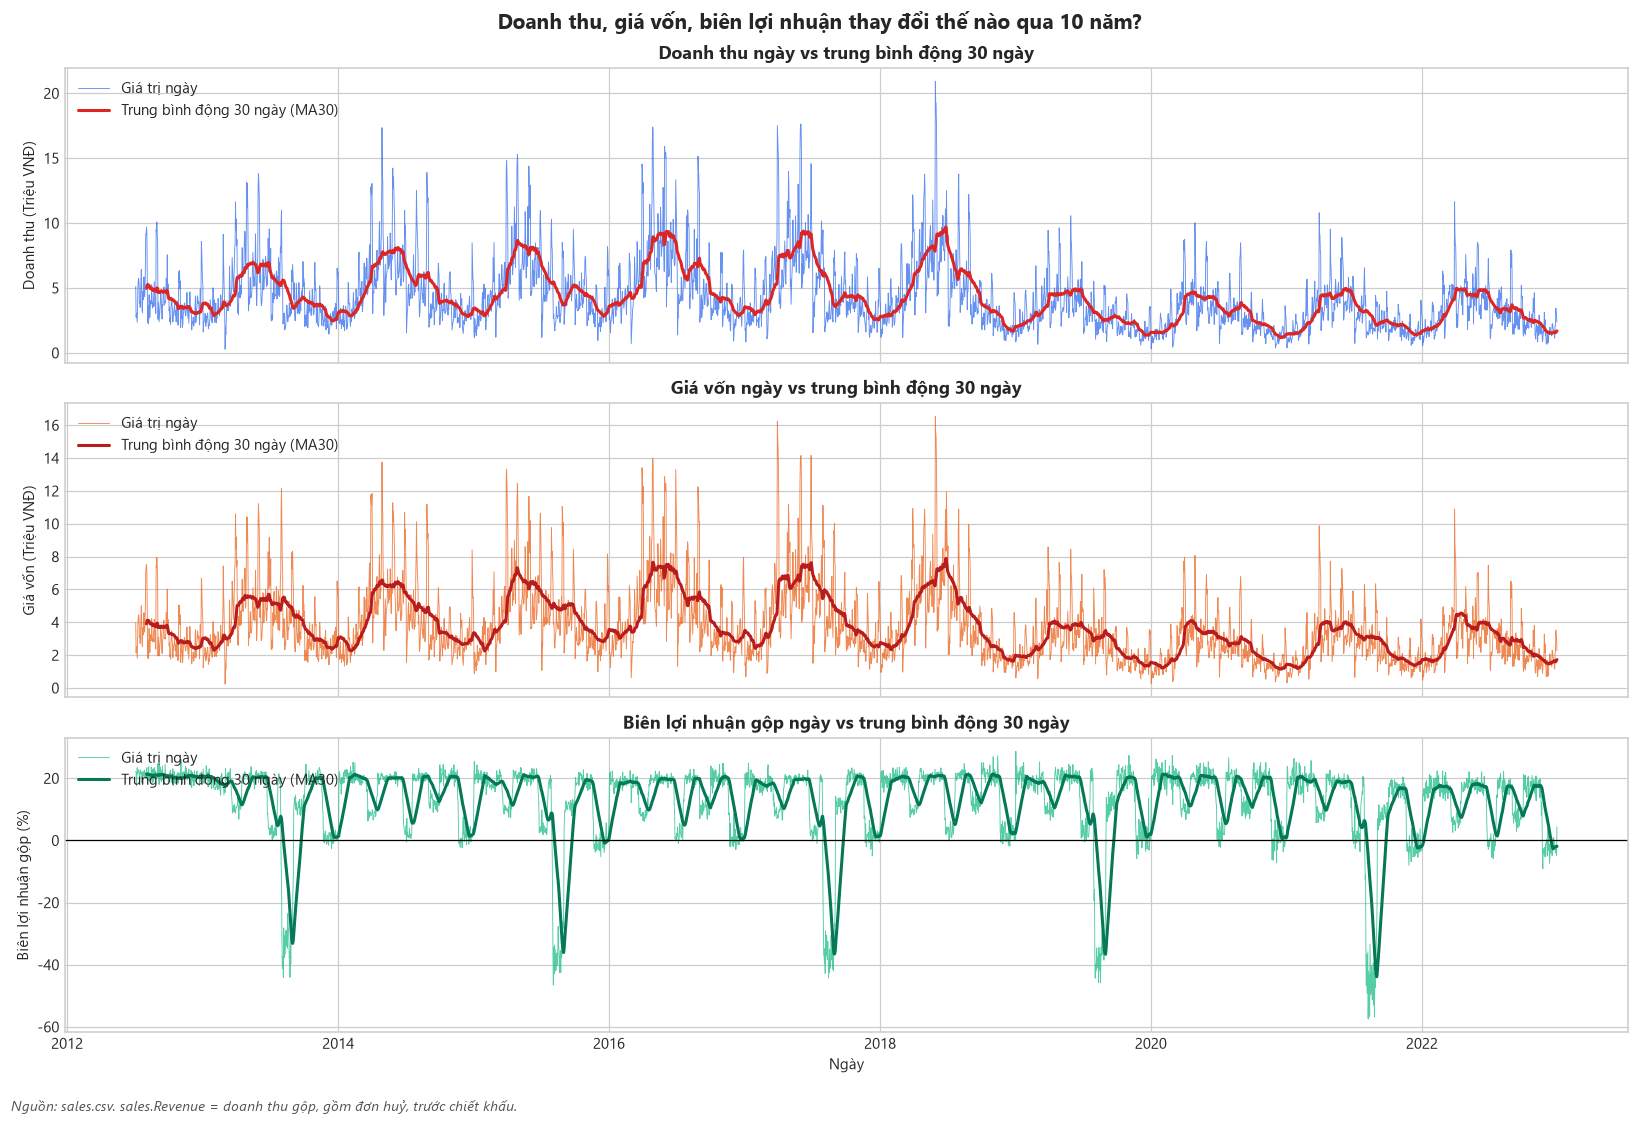

  đã lưu 01b_xu_huong_MA30.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
specs = [("Revenue", MILLION, "#2563eb", "#dc2626", f"Doanh thu ({UNIT})", "Doanh thu ngày vs trung bình động 30 ngày"),
         ("COGS", MILLION, "#ea580c", "#b91c1c", f"Giá vốn ({UNIT})", "Giá vốn ngày vs trung bình động 30 ngày"),
         ("Gross_Margin_Pct", 1, "#10b981", "#047857", "Biên lợi nhuận gộp (%)", "Biên lợi nhuận gộp ngày vs trung bình động 30 ngày")]
for ax, (col, scale, c1, c2, ylab, title) in zip(axes, specs):
    ax.plot(sales.Date, sales[col] / scale, color=c1, lw=0.6, alpha=0.7, label="Giá trị ngày")
    ax.plot(sales.Date, sales[col].rolling(30).mean() / scale, color=c2, lw=2, label="Trung bình động 30 ngày (MA30)")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylab)
    ax.legend(loc="upper left")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_xlabel("Ngày")
fig.suptitle("Doanh thu, giá vốn, biên lợi nhuận thay đổi thế nào qua 10 năm?", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, NOTE_SALES)
save_fig(fig, FIG / "01b_xu_huong_MA30.png")

In [6]:
yearly = sales.groupby("Year").agg(so_ngay=("Date", "count"), doanh_thu=("Revenue", "sum"), gia_von=("COGS", "sum"))
yearly["dt_trung_binh_ngay_trieu"] = yearly.doanh_thu / yearly.so_ngay / MILLION
yearly["bien_gop_pct"] = (1 - yearly.gia_von / yearly.doanh_thu) * 100
yearly["tang_truong_dt_ngay_pct"] = yearly.dt_trung_binh_ngay_trieu.pct_change() * 100
yearly.to_csv(TAB / "theo_nam.csv", encoding="utf-8-sig")
display(yearly.round(2))
key_numbers({
    "Năm có doanh thu TB/ngày cao nhất": f"{yearly.dt_trung_binh_ngay_trieu.idxmax()} ({yearly.dt_trung_binh_ngay_trieu.max():.2f} {UNIT}/ngày)",
    "Năm thấp nhất": f"{yearly.dt_trung_binh_ngay_trieu.idxmin()} ({yearly.dt_trung_binh_ngay_trieu.min():.2f} {UNIT}/ngày)",
    "2022 so với 2018 (DT TB/ngày)": f"{(yearly.loc[2022, 'dt_trung_binh_ngay_trieu'] / yearly.loc[2018, 'dt_trung_binh_ngay_trieu'] - 1) * 100:+.1f}%",
    "Năm 2012 chỉ có": f"{yearly.loc[2012, 'so_ngay']} ngày (từ 2012-07-04)",
})

,so_ngay,doanh_thu,gia_von,dt_trung_binh_ngay_trieu,bien_gop_pct,tang_truong_dt_ngay_pct
Year,,,,,,
2012,181,7.414977e+08,5.874619e+08,4.10,20.77,NaN
2013,365,1.657169e+09,1.465980e+09,4.54,11.54,10.83
2014,365,1.871846e+09,1.574607e+09,5.13,15.88,12.95
2015,365,1.889934e+09,1.665442e+09,5.18,11.88,0.97
2016,366,2.104641e+09,1.780559e+09,5.75,15.40,11.06
2017,365,1.911164e+09,1.694386e+09,5.24,11.34,-8.94
2018,365,1.850122e+09,1.542176e+09,5.07,16.64,-3.19
2019,365,1.136801e+09,1.005203e+09,3.11,11.58,-38.56
2020,366,1.054512e+09,8.860851e+08,2.88,15.97,-7.49


Số liệu chính:
  - Năm có doanh thu TB/ngày cao nhất: 2016 (5.75 Triệu VNĐ/ngày)
  - Năm thấp nhất: 2021 (2.86 Triệu VNĐ/ngày)
  - 2022 so với 2018 (DT TB/ngày): -36.8%
  - Năm 2012 chỉ có: 181 ngày (từ 2012-07-04)


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Doanh thu cao nhất vào thứ nào, tháng nào?

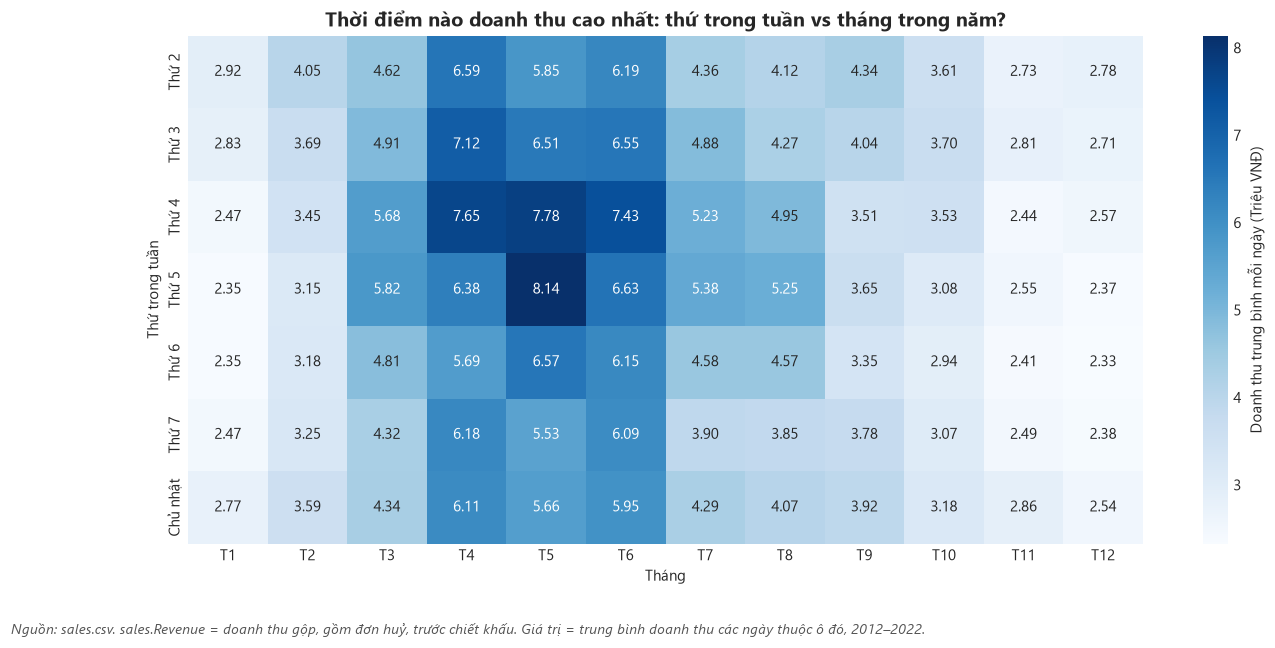

  đã lưu 01c_mua_vu_thu_thang.png


In [7]:
piv = sales.pivot_table(index="DayOfWeek", columns="Month", values="Revenue", aggfunc="mean") / MILLION
piv.index = ["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ nhật"]
piv.columns = [f"T{m}" for m in range(1, 13)]
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(piv, cmap="Blues", annot=True, fmt=".2f", cbar_kws={"label": f"Doanh thu trung bình mỗi ngày ({UNIT})"}, ax=ax)
ax.set_title("Thời điểm nào doanh thu cao nhất: thứ trong tuần vs tháng trong năm?", fontsize=13, fontweight="bold")
ax.set_xlabel("Tháng")
ax.set_ylabel("Thứ trong tuần")
source_note(fig, NOTE_SALES + " Giá trị = trung bình doanh thu các ngày thuộc ô đó, 2012–2022.")
save_fig(fig, FIG / "01c_mua_vu_thu_thang.png")

In [8]:
by_month = sales.groupby("Month").Revenue.mean() / MILLION
by_dow = sales.groupby("DayOfWeek").Revenue.mean() / MILLION
key_numbers({
    "Tháng cao nhất / thấp nhất (DT TB/ngày)": f"T{by_month.idxmax()} ({by_month.max():.2f}) / T{by_month.idxmin()} ({by_month.min():.2f}) {UNIT}",
    "Tỷ lệ tháng cao nhất / thấp nhất": f"{by_month.max() / by_month.min():.2f} lần",
    "Thứ cao nhất / thấp nhất": f"{piv.index[by_dow.idxmax()]} ({by_dow.max():.2f}) / {piv.index[by_dow.idxmin()]} ({by_dow.min():.2f}) {UNIT}",
    "Tỷ lệ thứ cao nhất / thấp nhất": f"{by_dow.max() / by_dow.min():.2f} lần",
})

Số liệu chính:
  - Tháng cao nhất / thấp nhất (DT TB/ngày): T5 (6.58) / T12 (2.52) Triệu VNĐ
  - Tỷ lệ tháng cao nhất / thấp nhất: 2.60 lần
  - Thứ cao nhất / thấp nhất: Thứ 4 (4.68) / Thứ 7 (3.91) Triệu VNĐ
  - Tỷ lệ thứ cao nhất / thấp nhất: 1.20 lần


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Tách chuỗi doanh thu tuần thành xu hướng + mùa vụ + phần dư (STL) thì thấy gì?

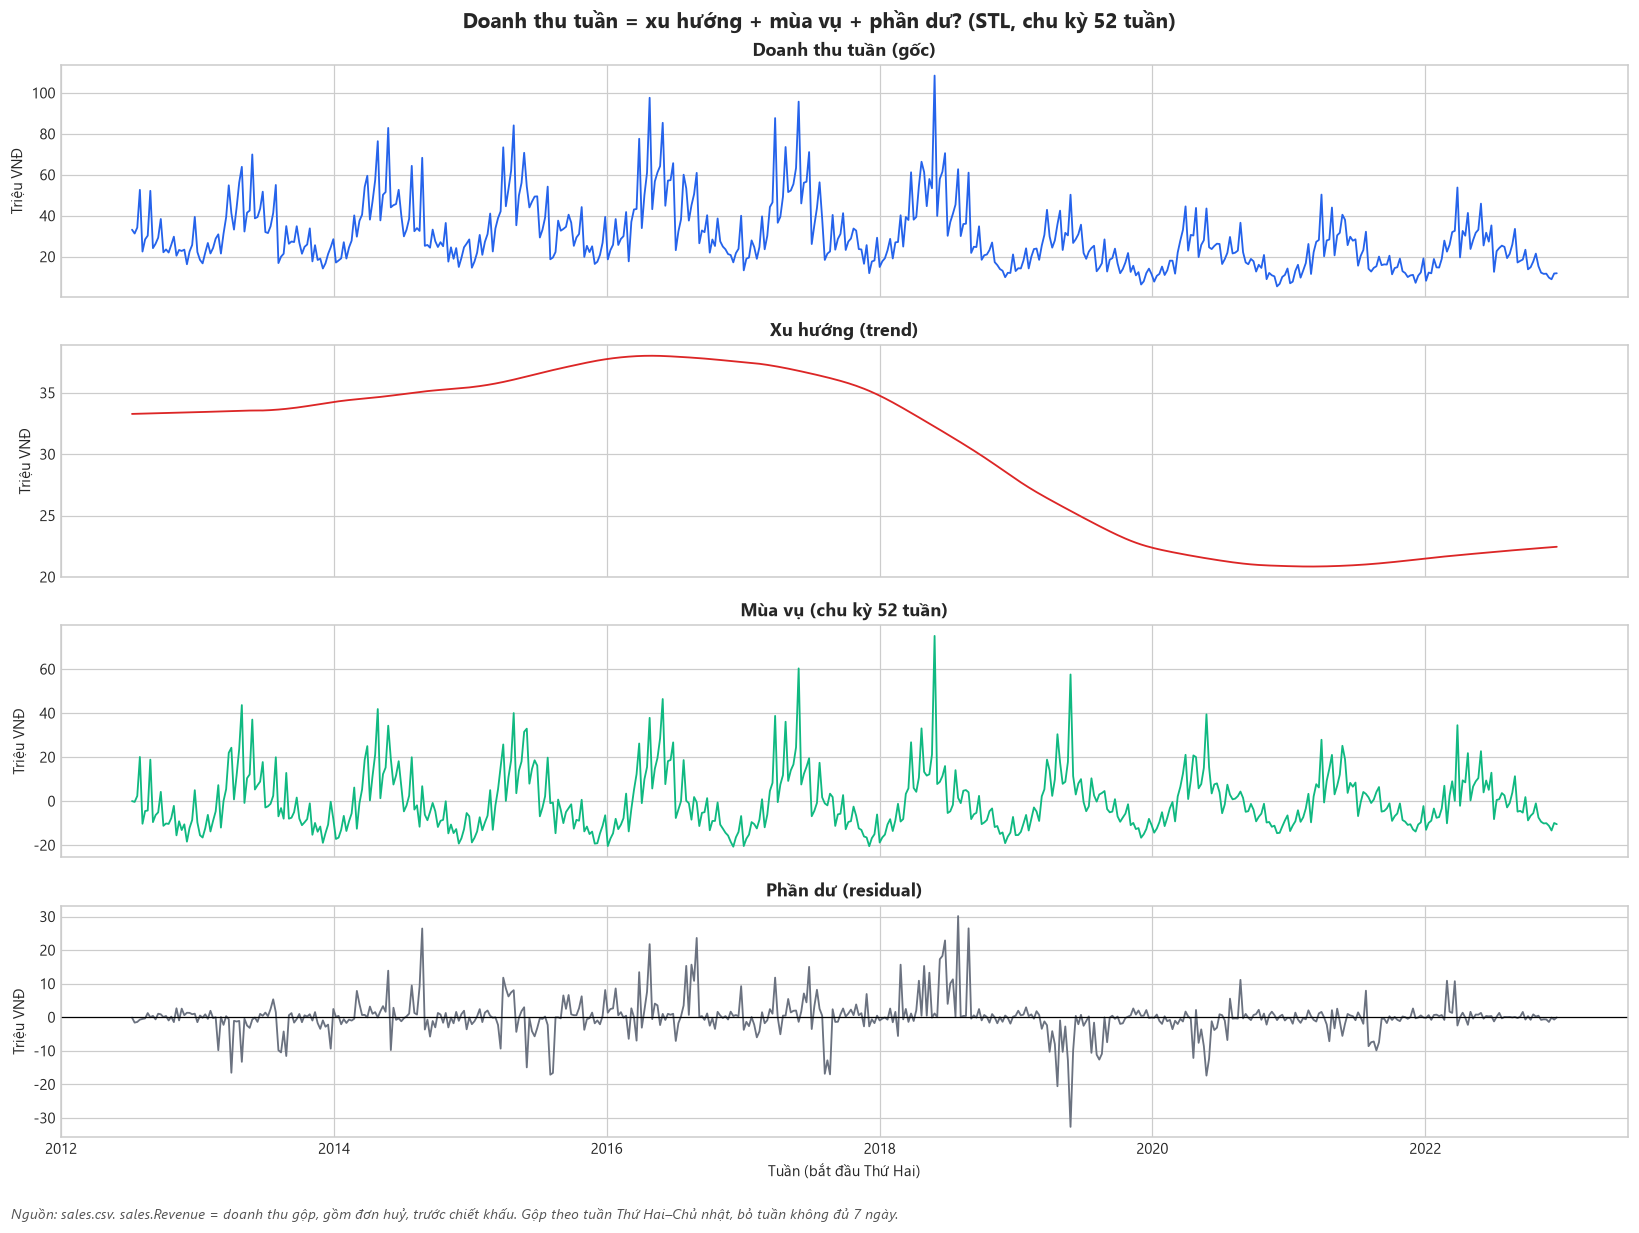

  đã lưu 01d_phan_ra_STL.png


In [9]:
from statsmodels.tsa.seasonal import STL

weekly = sales.set_index("Date").Revenue.resample("W-SUN").agg(["sum", "count"])   # tuần Thứ Hai → Chủ nhật
weekly.index = weekly.index - pd.Timedelta(days=6)           # nhãn = Thứ Hai đầu tuần
weekly = weekly[weekly["count"] == 7]["sum"] / MILLION       # bỏ tuần đầu/cuối không đủ 7 ngày
stl = STL(weekly, period=52, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
for ax, s, title, color in [(axes[0], weekly, "Doanh thu tuần (gốc)", "#2563eb"), (axes[1], stl.trend, "Xu hướng (trend)", "#dc2626"),
                            (axes[2], stl.seasonal, "Mùa vụ (chu kỳ 52 tuần)", "#10b981"), (axes[3], stl.resid, "Phần dư (residual)", "#6b7280")]:
    ax.plot(s.index, s.values, color=color, lw=1.2)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(UNIT)
axes[3].axhline(0, color="black", lw=0.8)
axes[3].set_xlabel("Tuần (bắt đầu Thứ Hai)")
fig.suptitle("Doanh thu tuần = xu hướng + mùa vụ + phần dư? (STL, chu kỳ 52 tuần)", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, NOTE_SALES + " Gộp theo tuần Thứ Hai–Chủ nhật, bỏ tuần không đủ 7 ngày.")
save_fig(fig, FIG / "01d_phan_ra_STL.png")

In [10]:
var = lambda x: np.nanvar(np.asarray(x))
f_trend = max(0, 1 - var(stl.resid) / var(stl.trend + stl.resid))
f_season = max(0, 1 - var(stl.resid) / var(stl.seasonal + stl.resid))
key_numbers({
    "Số tuần đủ 7 ngày": f"{len(weekly)} ({weekly.index.min().date()} → {weekly.index.max().date()})",
    "Độ mạnh xu hướng F_T (0–1)": f"{f_trend:.2f}",
    "Độ mạnh mùa vụ F_S (0–1)": f"{f_season:.2f}",
    "Biên độ mùa vụ (max − min)": f"{stl.seasonal.max() - stl.seasonal.min():.1f} {UNIT}/tuần",
    "Tuần có mùa vụ cao nhất trong năm": f"tuần thứ {stl.seasonal.groupby(stl.seasonal.index.isocalendar().week).mean().idxmax()} (ISO)",
})

Số liệu chính:
  - Số tuần đủ 7 ngày: 546 (2012-07-09 → 2022-12-19)
  - Độ mạnh xu hướng F_T (0–1): 0.64
  - Độ mạnh mùa vụ F_S (0–1): 0.85
  - Biên độ mùa vụ (max − min): 95.8 Triệu VNĐ/tuần
  - Tuần có mùa vụ cao nhất trong năm: tuần thứ 22 (ISO)


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …